# Ejercicio Pronósticos basados en series de tiempo

## María del Carmen Sac
## Juan Pablo Marroquín
## Ejercicio: **Pronósitico de Ocupados próximos 6 meses**


## **Ejercicio:**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses. Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.

## **1. Carga de paquetes**

En este momento cargaremos las librerieas que se utilizarán.

In [1]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


## **2. Carga de datos**

Revisaremos y leeremos el archivo de Excel. Carguemos los datos en un objeto que denominaremos data.

En ese archivo econtrarán la tasa de desempleo mensual de las 13 principales ciudades en Colombia (TD_13ciudades). El archivo también contiene series mensuales para las 13 principales ciudades de Colombia el número de ocupados en miles de personas (Ocupados), los desocupados (Desocupados) y los inactivos (Inactivos).

In [2]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

A continuación comenzaremos a utilizar y trabajar los valores de **Ocupados**, ya que es lo que nos pide la resolucion de este problema.



## **3. Graficamos la tasa de Ocupación**

(222, 4)


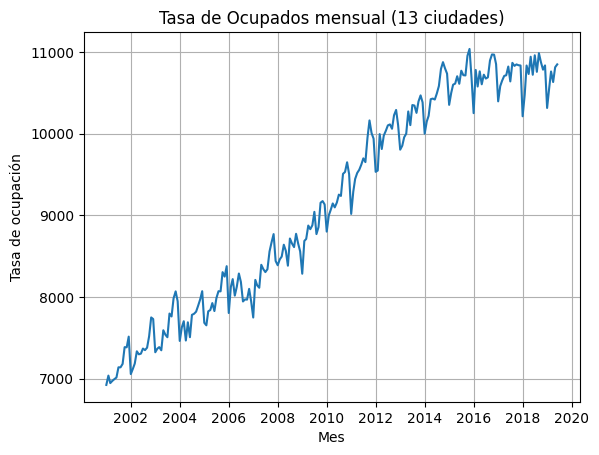

In [3]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("Tasa de Ocupados mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Tasa de ocupación")
plt.plot(data[["Ocupados"]])
plt.grid()
plt.show()

In [4]:
print(data.Ocupados)

mes
2001-01-01     6923.604
2001-02-01     7037.746
2001-03-01     6945.973
2001-04-01     6973.079
2001-05-01     6994.462
                ...    
2019-02-01    10557.917
2019-03-01    10760.776
2019-04-01    10632.028
2019-05-01    10813.000
2019-06-01    10848.000
Name: Ocupados, Length: 222, dtype: float64


## **4. Encontrando los componentes de la serie de tiempo (Ocupados)**

Comenzamos nuestro análisis descomponiendo la serie de tiempo en sus componentes: **tendencia**, **estacionalidad** y **componente puramente aleatorio**. (Empleando la función seasonal_decompose.)

Vemos que para el caso de Ocupados, estamos ante un modelo "aditivo" (los picos de la estacionalidad se mantien constantes).

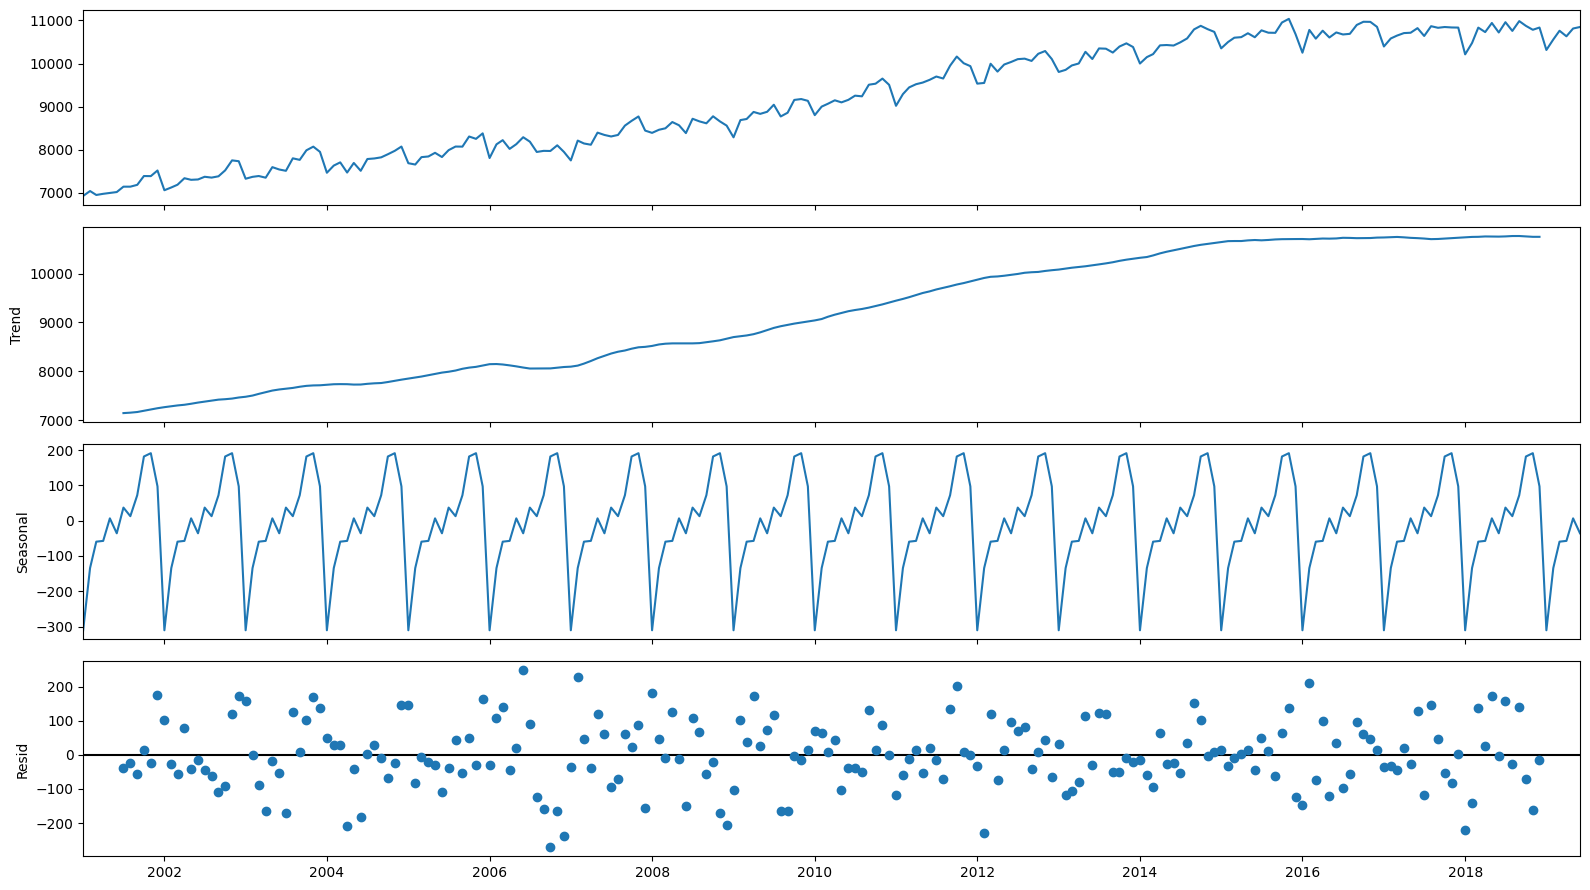

In [5]:
to_componentes = seasonal_decompose(data[["Ocupados"]],model="additive")
fig = to_componentes.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

Separando los elemientos de la serie, podemos observar la marcada estacionalidad de la serie. Igualmente como en los ultimos tres años, a partir del 2016, se da un **"aplanaiento"** de la tendencia, lo cual sera tomado en cuenta para nuestro trabajo de pronosito según el ejercicio.

In [6]:
to_componentes.seasonal
#to_componentes.trend
#to_componentes.resid

,seasonal
mes,
2001-01-01,-310.570069
2001-02-01,-134.331549
2001-03-01,-59.585841
2001-04-01,-57.385905
2001-05-01,6.435912
...,...
2019-02-01,-134.331549
2019-03-01,-59.585841
2019-04-01,-57.385905


La serie de Ocupados se caracteriza por una tendencia creciente histórica y una fuerte estacionalidad anual. Con fluctuaciones fuertes de los meses de enero y diciembre.

Antes de entrar a trabajar con los métodos de suavizamiento, vale la pena anotar que una forma sencilla y rápida para quitar el componente estacional (desestacionalizar) es restarle a la serie el componente estacional encontrado en la descomposición. Abajo podemos observar el resultado.

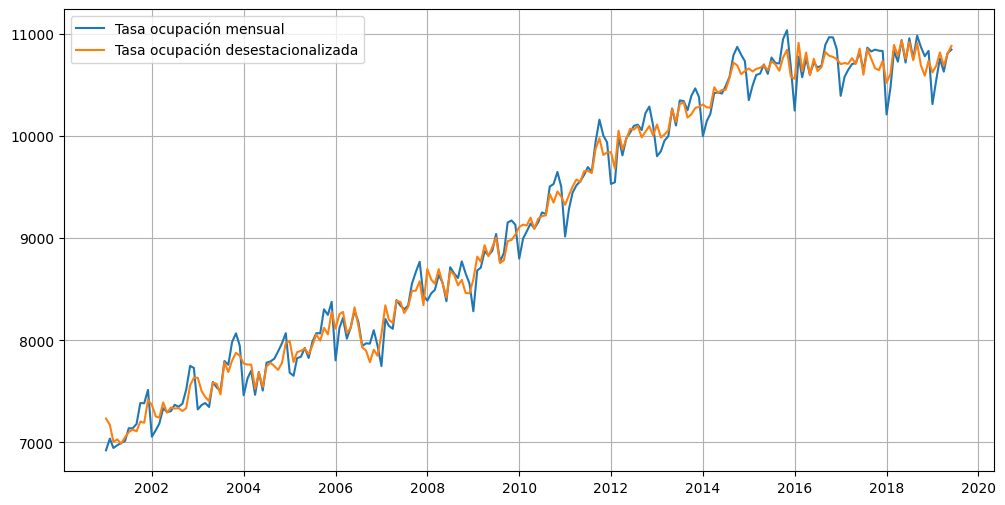

In [7]:
to_desestacionalizada = data["Ocupados"]-to_componentes.seasonal

fig = plt.figure(figsize=(12, 6))
plt.plot(data[["Ocupados"]],label="Tasa ocupación mensual")
plt.plot(to_desestacionalizada,label="Tasa ocupación desestacionalizada")
plt.legend()
plt.grid()
plt.show()


## **5. Protocolo de evaluación**

Antes de continuar es importante guardar una parte de la muestra para evaluar el comportamiento de los modelos por fuera de muestra (out-of-sample).

Guardaremos sies meses de datos, ya que es la pronostico que necesitamos realizar según el ejercicio. Esto nos servira para poder evaluar los resultados.

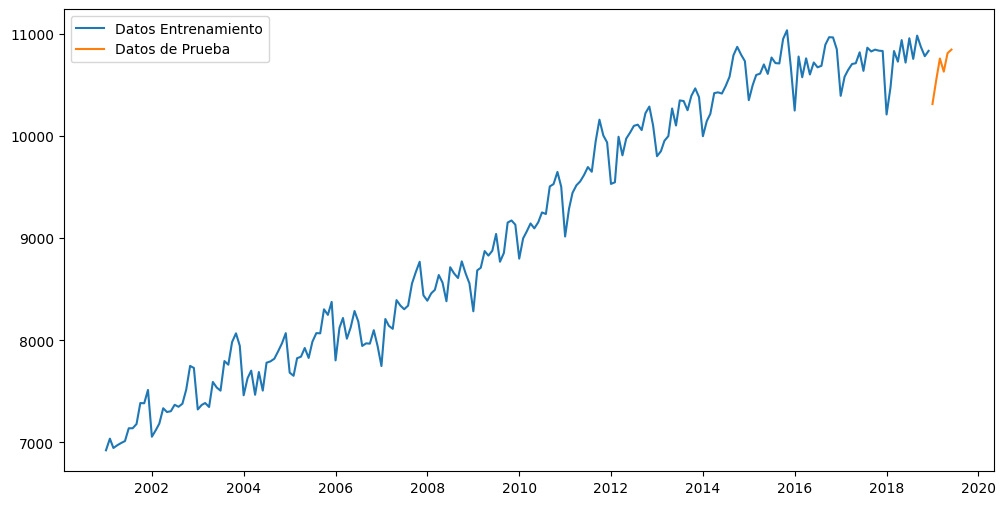

In [8]:
train_len = 216
train_to = data[["Ocupados"]][:train_len]
test_to = data[["Ocupados"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_to,label="Datos Entrenamiento")
plt.plot(test_to,label="Datos de Prueba")
plt.legend()
plt.show()

In [9]:
train_to

,Ocupados
mes,
2001-01-01,6923.604
2001-02-01,7037.746
2001-03-01,6945.973
2001-04-01,6973.079
2001-05-01,6994.462
...,...
2018-08-01,10756.782
2018-09-01,10984.928
2018-10-01,10874.338


In [10]:
test_to

,Ocupados
mes,
2019-01-01,10314.438
2019-02-01,10557.917
2019-03-01,10760.776
2019-04-01,10632.028
2019-05-01,10813.000
2019-06-01,10848.000


## **6. Promedio movil**

Para nuestro análisis de Promedio Movil, vemos que contamos con todos los datos, por lo que usaremos nuestra formula **"dato actual"**.

Tambien estamos consientes en nuestro analisis tampoco usaremos **"shift"**, ya que igualmente no hay datos faltantes en el ultimo perido. Esto tambien facilita el uso del **"min_periods"** dejandolo fijo en 2.

Para nuestro ejercicio, vamos a probar con varias ventanas: 2,3,4,5,6,8,10,12 y 14. Para evaluar cual nos funciona mejor.

In [11]:
## Considerando el dato actual
ma_2= train_to.rolling(2,min_periods=2).mean()
ma_3= train_to.rolling(3,min_periods=2).mean()
ma_4= train_to.rolling(4,min_periods=2).mean()
ma_5= train_to.rolling(5,min_periods=2).mean()
ma_6= train_to.rolling(6,min_periods=2).mean()
ma_8= train_to.rolling(8,min_periods=2).mean()
ma_10= train_to.rolling(10,min_periods=2).mean()
ma_12= train_to.rolling(12,min_periods=2).mean()
ma_14= train_to.rolling(14,min_periods=2).mean()


In [12]:
def fore_ma(datos, w, h):
  data=datos.copy()
  for x in range(1,h+1):
    ind = data.index[-1]
    value = ind + pd.DateOffset(months=1)
    data.loc[value]= data[-w:].mean()
  return data[-h:]

In [13]:
ma_2_f= fore_ma(train_to,2,6)
ma_3_f= fore_ma(train_to,3,6)
ma_4_f= fore_ma(train_to,4,6)
ma_5_f= fore_ma(train_to,5,6)
ma_6_f= fore_ma(train_to,6,6)
ma_8_f= fore_ma(train_to,8,6)
ma_10_f= fore_ma(train_to,10,6)
ma_12_f= fore_ma(train_to,12,6)
ma_14_f= fore_ma(train_to,14,6)

In [14]:
test_to

,Ocupados
mes,
2019-01-01,10314.438
2019-02-01,10557.917
2019-03-01,10760.776
2019-04-01,10632.028
2019-05-01,10813.000
2019-06-01,10848.000


In [15]:
ma_2_f

,Ocupados
mes,
2019-01-01,10809.348500
2019-02-01,10822.373250
2019-03-01,10815.860875
2019-04-01,10819.117063
2019-05-01,10817.488969
2019-06-01,10818.303016


In [16]:
rmse_ma_2 = np.sqrt(mean_squared_error(test_to,ma_2_f ))
rmse_ma_3 = np.sqrt(mean_squared_error(test_to,ma_3_f ))
rmse_ma_4 = np.sqrt(mean_squared_error(test_to,ma_4_f ))
rmse_ma_5 = np.sqrt(mean_squared_error(test_to,ma_5_f ))
rmse_ma_6 = np.sqrt(mean_squared_error(test_to,ma_6_f ))
rmse_ma_8 = np.sqrt(mean_squared_error(test_to,ma_8_f ))
rmse_ma_10 = np.sqrt(mean_squared_error(test_to,ma_10_f ))
rmse_ma_12 = np.sqrt(mean_squared_error(test_to,ma_12_f ))
rmse_ma_14 = np.sqrt(mean_squared_error(test_to,ma_14_f ))

In [17]:
print( rmse_ma_2, rmse_ma_3 ,rmse_ma_4 ,rmse_ma_5, rmse_ma_6, rmse_ma_8, rmse_ma_10, rmse_ma_12, rmse_ma_14)

242.8347290019203 250.36984465630144 270.6203851653251 266.5247179311155 272.83744069293607 270.14397611273165 263.23104811759316 225.30515014234717 215.78689456241435


In [30]:
rmse_data = { 'Orden MA': [2, 3, 4, 5, 6, 8, 10, 12, 14],'RMSE': [ rmse_ma_2, rmse_ma_3, rmse_ma_4, rmse_ma_5, rmse_ma_6,
        rmse_ma_8, rmse_ma_10, rmse_ma_12, rmse_ma_14 ]}
rmse_df = pd.DataFrame(rmse_data)
display(rmse_df.sort_values(by='RMSE'))

,Orden MA,RMSE
8,14,215.786895
7,12,225.305150
0,2,242.834729
1,3,250.369845
6,10,263.231048
3,5,266.524718
5,8,270.143976
2,4,270.620385
4,6,272.837441


La tabla anterior muestra los valores RMSE para cada orden del promedio móvil. Como puedes observar, el promedio móvil de orden 14 obtuvo el RMSE más bajo, lo que indica que fue el modelo más preciso para este conjunto de datos entre los probados.

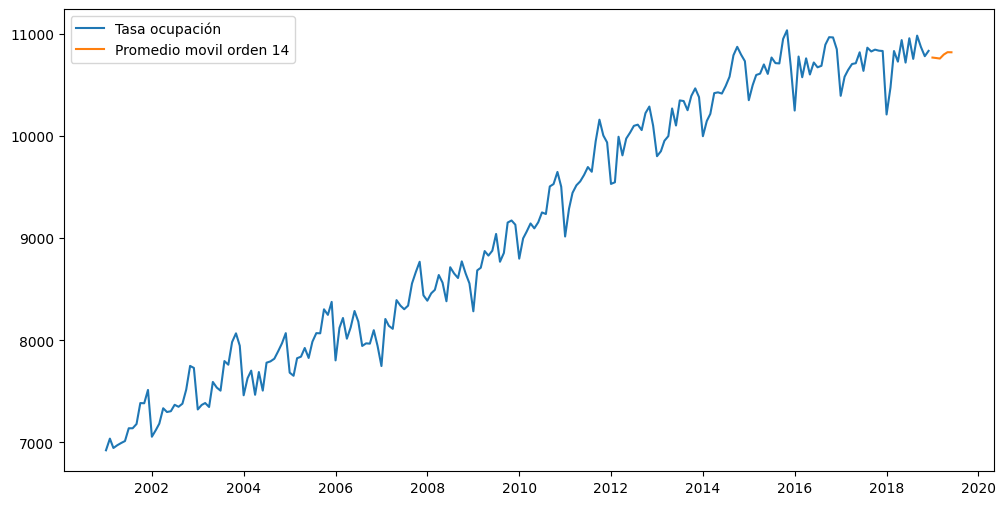

In [18]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_to,label="Tasa ocupación")
plt.plot(ma_14_f,label="Promedio movil orden 14")
plt.legend()
plt.show()

En la siguiente grafica podemos comparar los datos existententes utilizados para test, y los datos reslutantes del promedio movil 14.

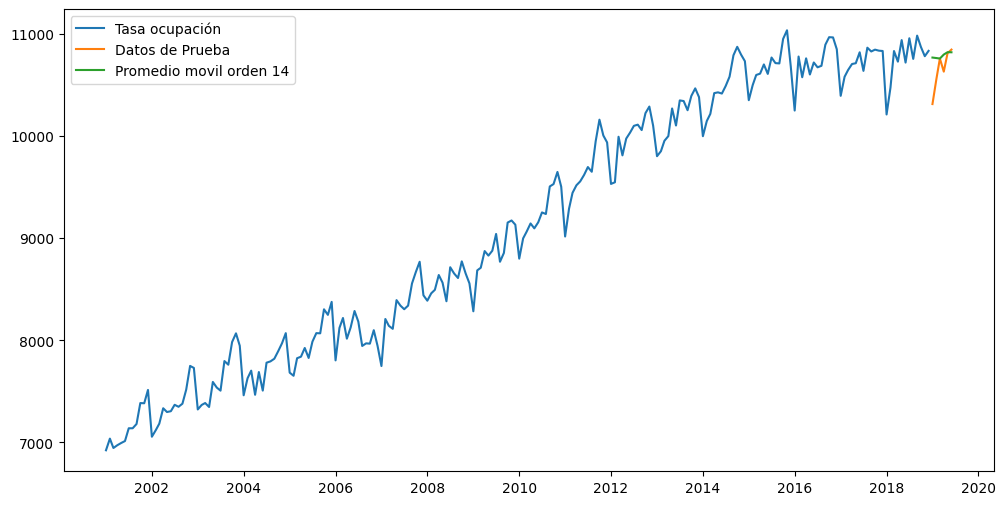

In [28]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_to,label="Tasa ocupación")
plt.plot(test_to,label="Datos de Prueba")
plt.plot(ma_14_f,label="Promedio movil orden 14")
plt.legend()
plt.show()

Ahora, vamos a generar un nuevo pronóstico para los próximos 6 meses, utilizando todos los datos disponibles hasta junio de 2019. Esto significa que los datos que antes eran de 'test' ahora serán parte de nuestro set de entrenamiento para el siguiente pronóstico. Tomar en cuenta que usaremos la ventana de 14 que nos dio el RMSE más bajo.

In [31]:

new_train_to = data[['Ocupados']]
# Actualizar el conjunto de entrenamiento para incluir los datos hasta junio de 2019, 'data' ya contiene todos los valores hasta 2019-06-01
forecast_jul_dec_2019 = fore_ma(new_train_to, 14, 6)
# Generar el nuevo pronóstico para los próximos 6 meses (Julio a Diciembre de 2019).Usaremos el mismo orden 14 del promedio móvil que resultó con el RMSE más bajo
display(forecast_jul_dec_2019)

,Ocupados
mes,
2019-07-01,10770.167214
2019-08-01,10757.943872
2019-09-01,10760.586578
2019-10-01,10746.400119
2019-11-01,10745.658556
2019-12-01,10728.567881


## **7. Pronóstico**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades y tras nuestro análisis para el mejor pronositco con promedios moviles, procedemos a visualizar la serie completa de 'Ocupados' junto con este nuevo pronóstico de 6 meses.

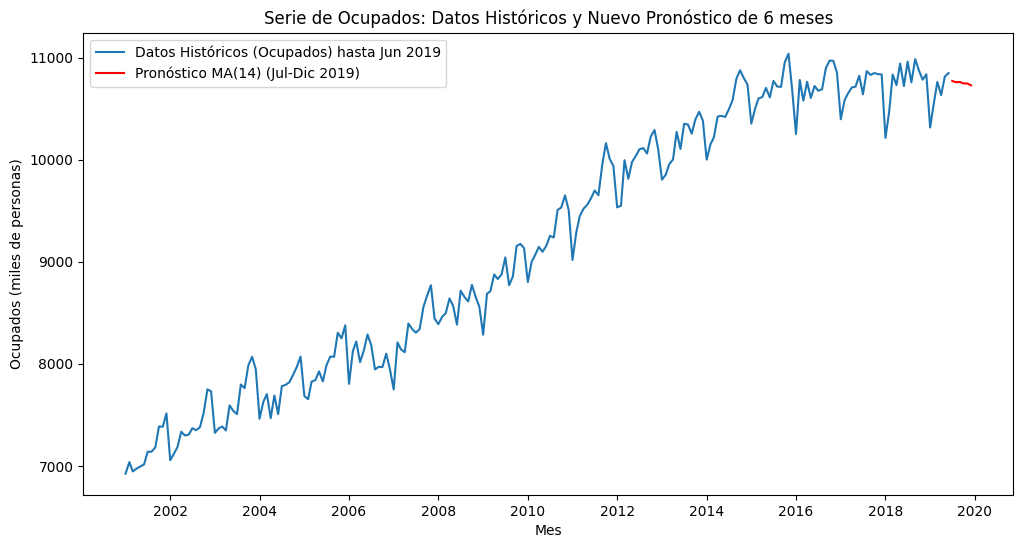

In [24]:
fig = plt.figure(figsize=(12, 6))
plt.plot(new_train_to, label='Datos Históricos (Ocupados) hasta Jun 2019')
plt.plot(forecast_jul_dec_2019, label='Pronóstico MA(14) (Jul-Dic 2019)', color='red')
plt.title('Serie de Ocupados: Datos Históricos y Nuevo Pronóstico de 6 meses')
plt.xlabel('Mes')
plt.ylabel('Ocupados (miles de personas)')
plt.legend()
plt.show()

## **8. Conclusión y Limitaciones**

**Resumen de los Resultados**

En este ejercicio, hemos buscado el mejor pronóstico para el número de ocupados en las 13 principales ciudades de Colombia para los próximos 6 meses (Julio a Diciembre de 2019), utilizando el método de Promedios Móviles. Tras evaluar diferentes órdenes de promedio móvil (MA), el modelo con un *orden de 14 (MA(14))* resultó ser el más preciso, obteniendo el *RMSE más bajo de 215.79*.

La serie de ocupados ha mostrado una tendencia creciente histórica con una marcada estacionalidad anual. Sin embargo, se observó un "aplanamiento" de la tendencia a partir del 2016.

**Limitaciones del Pronóstico**

Es importante no perder de vista estos puntos:

1.  **Naturaleza del Promedio Móvil:** El promedio móvil es un método de pronóstico simple que se basa en el promedio de datos pasados. Esto significa que es un indicador que no puede reaccionar rápidamente a cambios repentinos en la tendencia o eventos inesperados que afecten el número de ocupados. Como vemos en los resultados.
2.  **Omisión de Estacionalidad:** Aunque la serie histórica mostró una fuerte estacionalidad, el pronóstico de promedio móvil no proyecta directamente el componente estacional en la pronóstico. Al ser un promedio, tiende a suavizar las fluctuaciones, lo que puede llevar a una subestimación de los picos y valles que probablemente continuarían en la serie real.
3.  **Tendencia Constante:** El modelo de promedio móvil asume que la tendencia futura será una continuación del promedio de los últimos 14 periodos. Dada la observación de un "aplanamiento" de la tendencia en los últimos años, un promedio móvil podría ofrecer un pronóstico relativamente plano que no capte una posible las variaciones que se dan en la realidad.
4.  **No Toma en Cuenta Factores Externos:** Este pronóstico es puramente univariado, es decir, solo utiliza la serie histórica de ocupados. No tiene en cuenta factores macroeconómicos, políticas gubernamentales, eventos sociales o económicos (como crisis que sabemos hubo en el 2020 con el COVID) que podrían influir significativamente en los resultados futuros.